In [6]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from experiment_utils import run_one_experiment, save_result_v1, run, MLPClassifier

In [2]:
FEATURE_COLS = [
    "home_rank",
    "away_rank",
    "home_elo",
    "away_elo",
    "home_form_ema33",
    "away_form_ema33"
]

data = pd.read_csv("../data/Processed_Project_Data/fifa_and_elo_with_ema.csv")

data = data.drop(columns=["Unnamed: 0"], errors="ignore")

data["date"] = pd.to_datetime(data["date"], format="mixed")
data = data.sort_values("date").reset_index(drop=True)

data = data.dropna(subset=FEATURE_COLS + ["result"]).reset_index(drop=True)

X = data[FEATURE_COLS].values.astype(np.float32)

y = (data["result"].values + 1).astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_s, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("Train size:", len(X_train_tensor), "Test size:", len(X_test_tensor))


Train size: 888 Test size: 222


In [3]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 0.8587 | val loss = 0.7307 | val acc = 0.6742
Epoch 100/1000 | train loss = 0.8350 | val loss = 0.7301 | val acc = 0.6685
Epoch 150/1000 | train loss = 0.8409 | val loss = 0.7367 | val acc = 0.6685
Epoch 200/1000 | train loss = 0.8391 | val loss = 0.7392 | val acc = 0.6517
Epoch 250/1000 | train loss = 0.8192 | val loss = 0.7403 | val acc = 0.6685
Epoch 300/1000 | train loss = 0.8181 | val loss = 0.7466 | val acc = 0.6517
Epoch 350/1000 | train loss = 0.7974 | val loss = 0.7463 | val acc = 0.6461
Epoch 400/1000 | train loss = 0.7833 | val loss = 0.7536 | val acc = 0.6404
Epoch 450/1000 | train loss = 0.7805 | val loss = 0.7605 | val acc = 0.6404
Epoch 500/1000 | train loss = 0.7563 | val loss = 0.7690 | val acc = 0.6348
Epoch 550/1000 | train loss = 0.7794 | val loss = 0.7713 | val acc = 0.6067
Epoch 600/1000 | train loss = 0.7594 | val loss = 0.7759 | val acc = 0.6404
Epoch 650/1000 | train loss = 0.7370 | val loss = 0.7937 | val acc = 0.6404
Epoch 700/100

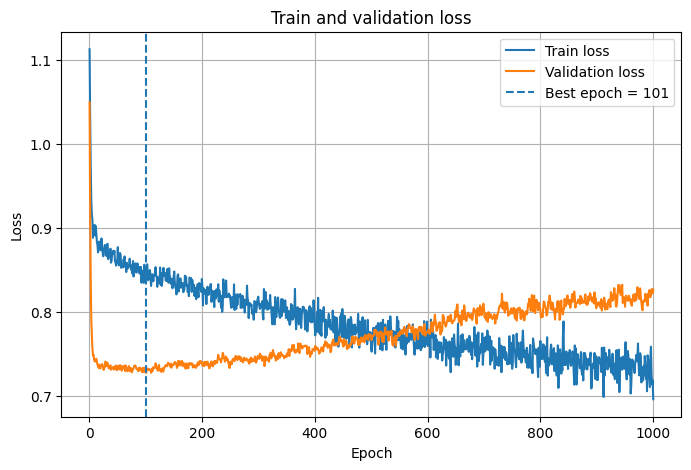

0.6711711711711712

In [4]:
run_one_experiment(model, criterion, optimizer, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor)

In [5]:
best_num_epochs = 101

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.6712 | Precision: 0.6358 | Recall: 0.5889 | Specificity: 0.8148 | F1: 0.5722

Run 2/10
Accuracy: 0.6532 | Precision: 0.4319 | Recall: 0.5464 | Specificity: 0.7992 | F1: 0.4824

Run 3/10
Accuracy: 0.6667 | Precision: 0.7720 | Recall: 0.5636 | Specificity: 0.8045 | F1: 0.5150

Run 4/10
Accuracy: 0.6667 | Precision: 0.6065 | Recall: 0.5717 | Specificity: 0.8139 | F1: 0.5342

Run 5/10
Accuracy: 0.6622 | Precision: 0.6077 | Recall: 0.5684 | Specificity: 0.8071 | F1: 0.5474

Run 6/10
Accuracy: 0.6622 | Precision: 0.7726 | Recall: 0.5523 | Specificity: 0.7990 | F1: 0.4998

Run 7/10
Accuracy: 0.6577 | Precision: 0.6003 | Recall: 0.5554 | Specificity: 0.8032 | F1: 0.5076

Run 8/10
Accuracy: 0.6622 | Precision: 0.5846 | Recall: 0.5644 | Specificity: 0.8065 | F1: 0.5400

Run 9/10
Accuracy: 0.6622 | Precision: 0.6054 | Recall: 0.5625 | Specificity: 0.8056 | F1: 0.5224

Run 10/10
Accuracy: 0.6577 | Precision: 0.4326 | Recall: 0.5515 | Specificity: 0.8020 | F1: 0.4848

Summary o

In [8]:
save_result_v1(
    experiment_name="Experiment_3-2_ranks_EMA_best",
    summary=summary
)


Saved result for Experiment_3-2_ranks_EMA_best
File: ../results/experiment_summary_v1.csv
